In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.preprocessing import load_data, preprocess
from src.features.engineering import build_features, FEATURE_COLS

train_raw, test_raw = load_data('../data/raw/train.csv', '../data/raw/test.csv')

print("✅ Train:", train_raw.shape)
print("✅ Test:", test_raw.shape)

✅ Train: (577347, 12)
✅ Test: (247435, 11)


In [2]:
# Preprocess (encode categoricals, drop raw text cols)
train_prep = preprocess(train_raw)
test_prep  = preprocess(test_raw)

# Feature engineering
train_feat = build_features(train_prep)
test_feat  = build_features(test_prep)

print("✅ Train after FE:", train_feat.shape)
print("✅ Test after FE:", test_feat.shape)
print("\n📋 New columns added:")
new_cols = [c for c in train_feat.columns if c not in train_raw.columns]
print(new_cols)

✅ Train after FE: (577347, 29)
✅ Test after FE: (247435, 28)

📋 New columns added:
['spectral_type_enc', 'galaxy_population_enc', 'u_g', 'g_r', 'r_i', 'i_z', 'g_i', 'r_z', 'u_r', 'g_z', 'band_mean', 'band_std', 'band_min', 'band_max', 'band_range', 'redshift_log1p', 'redshift_sq', 'is_high_z', 'is_star_z']


In [3]:
# Check all required feature cols exist
missing = [c for c in FEATURE_COLS if c not in train_feat.columns]
print("❌ Missing features:", missing if missing else "None — all good!")

# Check no nulls introduced
nulls = train_feat[FEATURE_COLS].isnull().sum()
print("\n🔍 Null check:")
print(nulls[nulls > 0] if nulls.any() else "✅ No nulls in any feature column")

train_feat[FEATURE_COLS].describe().T[['mean','std','min','max']]

❌ Missing features: None — all good!

🔍 Null check:
✅ No nulls in any feature column


,mean,std,min,max
alpha,181.616673,96.242941,1.168375e-02,359.999810
delta,21.834654,18.933570,-1.796699e+01,79.158322
u,22.441926,2.018135,-1.392249e-01,28.253263
g,21.007273,1.795426,1.353548e+01,27.620208
r,19.962811,1.648964,1.257941e+01,25.254499
i,19.378911,1.580059,1.196278e+01,27.910853
z,19.041136,1.584365,1.168280e+01,26.826867
redshift,0.723135,0.810070,-9.970358e-03,7.010780
u_g,1.434652,1.142003,-2.315586e+01,7.523080
g_r,1.044463,0.736291,-8.104372e+00,8.874428


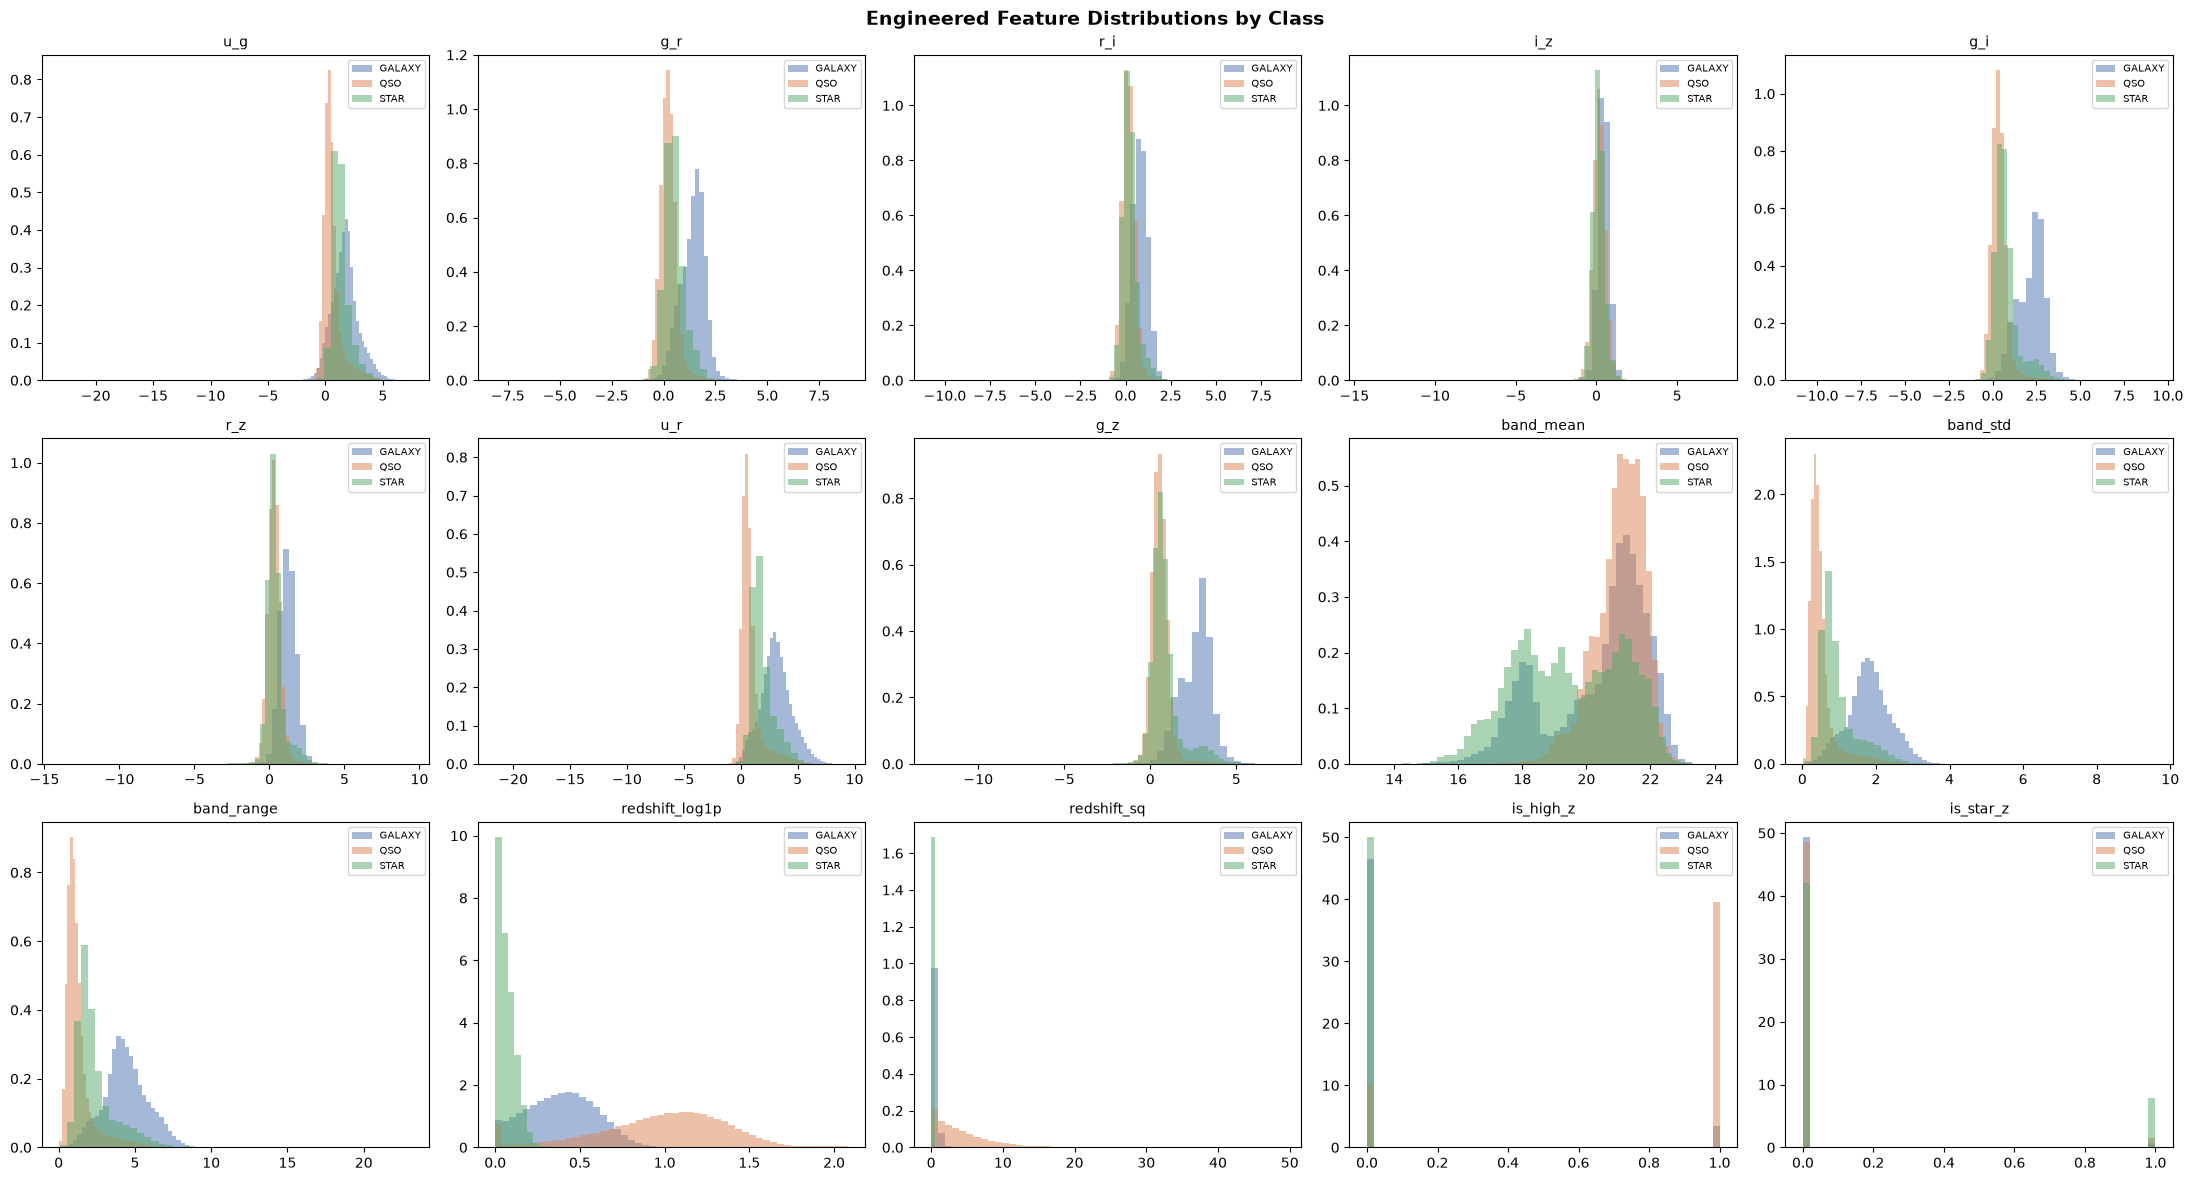

✅ Chart saved!


In [4]:
new_features = ['u_g','g_r','r_i','i_z','g_i','r_z','u_r','g_z',
                'band_mean','band_std','band_range',
                'redshift_log1p','redshift_sq','is_high_z','is_star_z']

classes = ['GALAXY','QSO','STAR']
colors_v = ['#4C72B0','#DD8452','#55A868']

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for idx, feat in enumerate(new_features):
    for cls, color in zip(classes, colors_v):
        subset = train_feat[train_feat['class']==cls][feat]
        axes[idx].hist(subset, bins=50, alpha=0.5, label=cls, color=color, density=True)
    axes[idx].set_title(feat, fontsize=10)
    axes[idx].legend(fontsize=7)

plt.suptitle('Engineered Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../eda_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

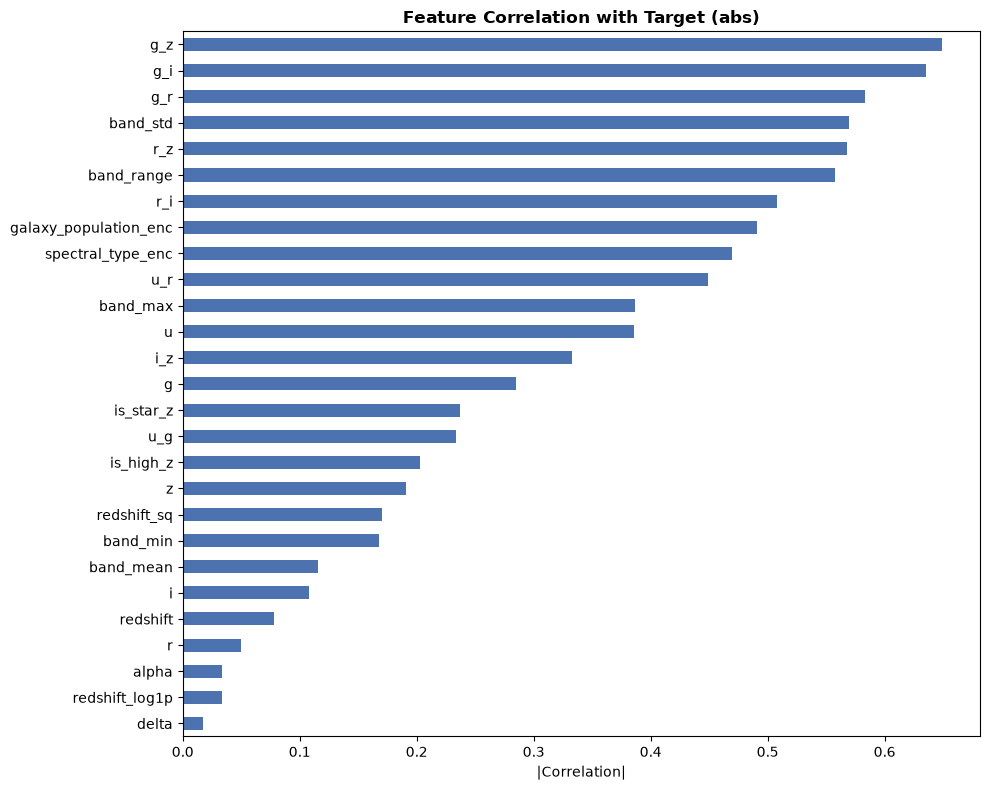


🏆 Top 10 features by correlation:
g_z                      0.649074
g_i                      0.635034
g_r                      0.583357
band_std                 0.569432
r_z                      0.567993
band_range               0.557203
r_i                      0.507789
galaxy_population_enc    0.490872
spectral_type_enc        0.469770
u_r                      0.449060
Name: class_enc, dtype: float64


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_feat['class_enc'] = le.fit_transform(train_feat['class'])

corr_with_target = train_feat[FEATURE_COLS + ['class_enc']].corr()['class_enc'].drop('class_enc')
corr_with_target = corr_with_target.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr_with_target.plot(kind='barh', color='#4C72B0')
plt.title('Feature Correlation with Target (abs)', fontweight='bold')
plt.xlabel('|Correlation|')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../feature_importance_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🏆 Top 10 features by correlation:")
print(corr_with_target.head(10))

In [6]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Prepare final train
X_train_final = train_feat[FEATURE_COLS].copy()
y_train_final = train_feat['class'].copy()

# Prepare final test
X_test_final = test_feat[FEATURE_COLS].copy()

# Save
X_train_final.to_csv('../data/processed/X_train.csv', index=False)
y_train_final.to_csv('../data/processed/y_train.csv', index=False)
X_test_final.to_csv('../data/processed/X_test.csv', index=False)

# Verify
print("✅ Saved:")
print(f"   X_train: {X_train_final.shape}")
print(f"   y_train: {y_train_final.shape}")
print(f"   X_test:  {X_test_final.shape}")
print(f"\n📋 Feature columns ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

✅ Saved:
   X_train: (577347, 27)
   y_train: (577347,)
   X_test:  (247435, 27)

📋 Feature columns (27):
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z', 'g_i', 'r_z', 'u_r', 'g_z', 'band_mean', 'band_std', 'band_min', 'band_max', 'band_range', 'redshift_log1p', 'redshift_sq', 'is_high_z', 'is_star_z', 'spectral_type_enc', 'galaxy_population_enc']
